# Project Title: Customer Churn Analysis and Prediction
## Project Overview:
<p>The project aims to analyze customer churn in a
telecommunications company and develop
predictive models to identify at-risk customers. The
ultimate goal is to provide actionable insights and
recommendations to reduce churn and improve
customer retention.</p>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Tasks 1: Data Preparation
<h4>Description:</h4>
<ul>
    <li><p>Load and preprocess the dataset,
addressing missing values, and encoding
categorical variables for machine learning
readiness.</p></li>
</ul>

<hr>
<h4>Skills:</h4>
<ul>
    <li><p>Data preprocessing techniques.</p></li>
    <li><p>Handling missing values.</p></li>
    <li><p>Categorical variable encoding.</p></li>
</ul>

In [6]:
df = pd.read_csv("Telco_Customer_Churn_Dataset.csv")

In [7]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [12]:
df.shape

(7043, 21)

In [13]:
df.drop('customerID',axis=1,inplace=True)

## Checking Missing Values

In [14]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

<h4>As we see above there are not any missing or null values in dataset</h4>

<h4>Categorical variable encoding by using Sklearn Library</h4>

In [15]:
df['TotalCharges'].loc[df['TotalCharges']==' ']

488      
753      
936      
1082     
1340     
3331     
3826     
4380     
5218     
6670     
6754     
Name: TotalCharges, dtype: str

In [16]:
df['TotalCharges'][488]

' '

In [17]:
df['TotalCharges'] = df['TotalCharges'].str.strip()  # remove spaces
print(df['TotalCharges'].dtype)
df['TotalCharges'] = df['TotalCharges'].replace('', '0')
df['TotalCharges'] = df['TotalCharges'].astype(float)
print(df['TotalCharges'].dtype)

str
float64


In [18]:
df_obj=df.select_dtypes(include="object")
#df.gender = df.gender.astype("category")


C:\Users\pc\AppData\Local\Temp\ipykernel_10596\3354285250.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_obj=df.select_dtypes(include="object")


In [19]:
for i in df_obj:
    print(i , " :" ,df[i].unique())

gender  : <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner  : <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents  : <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService  : <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines  : <ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService  : <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity  : <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup  : <ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection  : <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport  : <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV  : <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies  : <ArrowStringArray>
['No', 'Yes', 'No internet serv

In [20]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


# EDA (Exploratory Data Analysis)

In [21]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [22]:
print(df['TotalCharges'].skew())

0.963234654832277


In [23]:
print(df['tenure'].skew())

0.2395397495619829


In [24]:
print(df['MonthlyCharges'].skew())

-0.22052443394398033


## Graphs

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
charges_by_gender=df.groupby('gender')['TotalCharges'].sum().reset_index()

In [27]:
charges_by_gender['per']=(charges_by_gender['TotalCharges']/charges_by_gender['TotalCharges'].sum())*100

In [28]:
charges_by_gender['per']=charges_by_gender['per'].astype(int)

In [29]:
charges_by_gender

,gender,TotalCharges,per
0,Female,7952354.2,49
1,Male,8103814.5,50


Text(0.5, 1.0, 'Total Charges Paid by Gender')

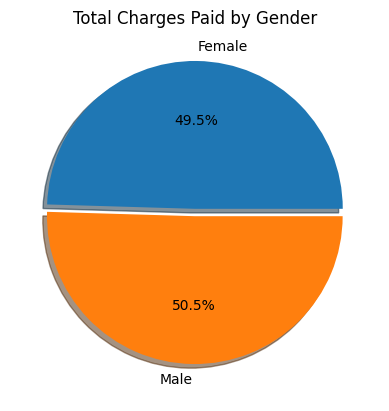

In [30]:
plt.pie(charges_by_gender['TotalCharges'],explode=[0.05,0],labels=["Female","Male"],autopct="%1.1f%%",shadow=True)
plt.title("Total Charges Paid by Gender")


Text(0.5, 1.0, 'No. of Payments Mode used')

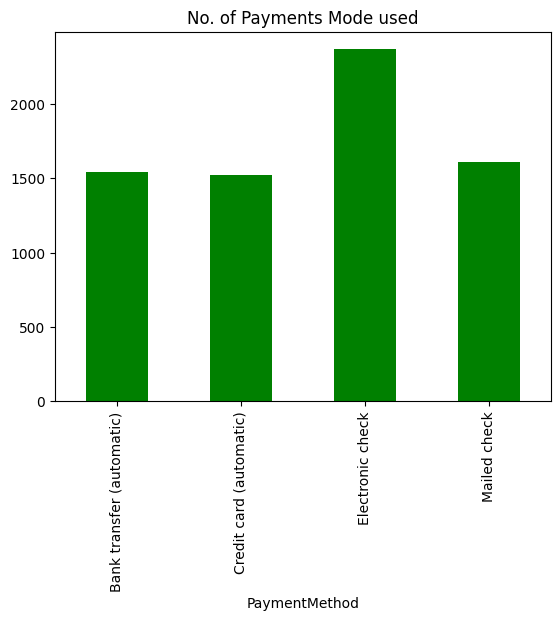

In [31]:
df.groupby('PaymentMethod')['PaymentMethod'].value_counts().plot(kind='bar',color='green')
plt.title("No. of Payments Mode used")

In [32]:
group_=df.groupby(['InternetService','gender','Churn'])['InternetService'].value_counts().reset_index()

In [33]:
group_

,InternetService,gender,Churn,count
0,DSL,Female,No,969
1,DSL,Female,Yes,219
2,DSL,Male,No,993
3,DSL,Male,Yes,240
4,Fiber optic,Female,No,889
5,Fiber optic,Female,Yes,664
6,Fiber optic,Male,No,910
7,Fiber optic,Male,Yes,633
8,No,Female,No,691
9,No,Female,Yes,56


<Axes: title={'center': 'Internet Services Churn by Gender'}, xlabel='gender,InternetService,Churn'>

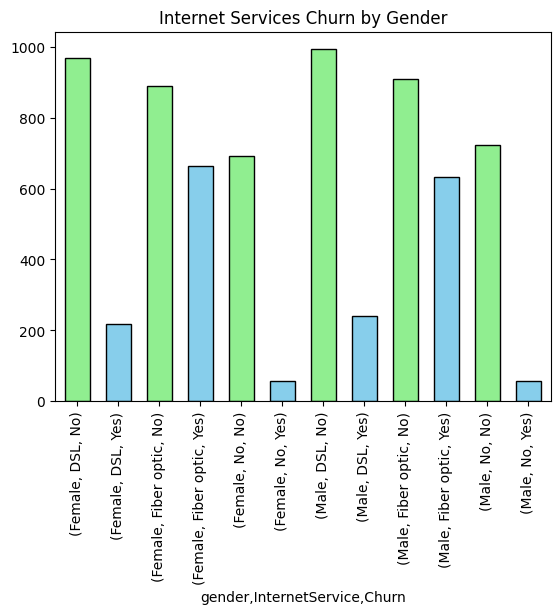

In [34]:
df.groupby(['gender','InternetService','Churn'])['gender'].value_counts().plot(kind='bar',color=['lightgreen','skyblue'],width=0.6,title="Internet Services Churn by Gender",edgecolor="black")

(array([1101.,  547.,  404.,  337.,  312.,  270.,  272.,  270.,  235.,
         180.,  190.,  135.,  123.,  121.,  116.,  104.,   93.,  115.,
          99.,   92.,  100.,   79.,   99.,  100.,   82.,   80.,   86.,
          86.,  102.,   60.,   71.,   75.,   93.,   74.,   83.,   62.,
          73.,   62.,   58.,   56.,   57.,   44.,   44.,   44.,   35.,
          41.,   29.,   26.,   18.,    8.]),
 array([   0.   ,  173.696,  347.392,  521.088,  694.784,  868.48 ,
        1042.176, 1215.872, 1389.568, 1563.264, 1736.96 , 1910.656,
        2084.352, 2258.048, 2431.744, 2605.44 , 2779.136, 2952.832,
        3126.528, 3300.224, 3473.92 , 3647.616, 3821.312, 3995.008,
        4168.704, 4342.4  , 4516.096, 4689.792, 4863.488, 5037.184,
        5210.88 , 5384.576, 5558.272, 5731.968, 5905.664, 6079.36 ,
        6253.056, 6426.752, 6600.448, 6774.144, 6947.84 , 7121.536,
        7295.232, 7468.928, 7642.624, 7816.32 , 7990.016, 8163.712,
        8337.408, 8511.104, 8684.8  ]),
 <BarContainer o

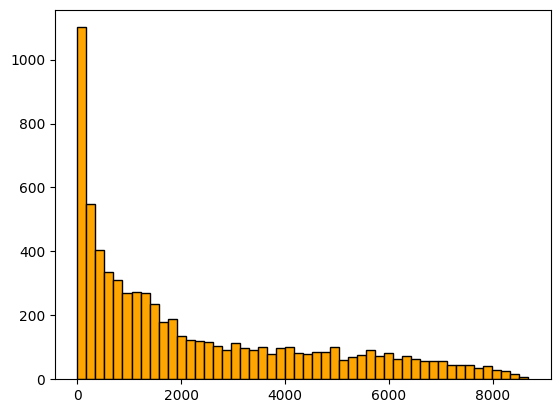

In [35]:
plt.hist(df['TotalCharges'],bins=50,color="orange",edgecolor="black")

<Figure size 1600x500 with 0 Axes>

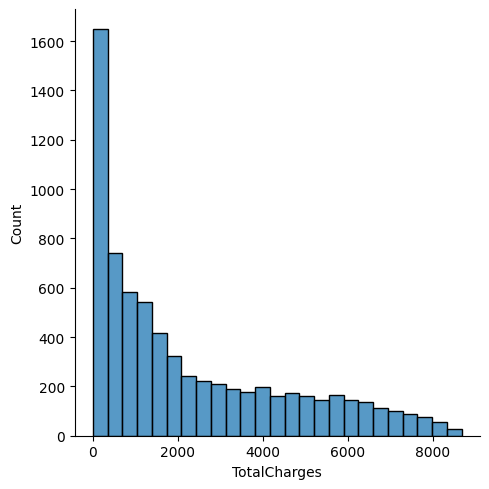

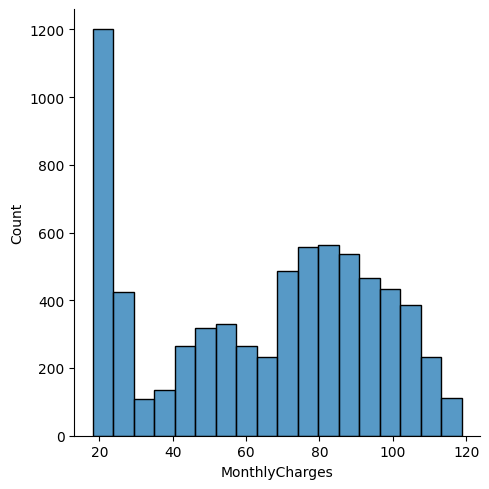

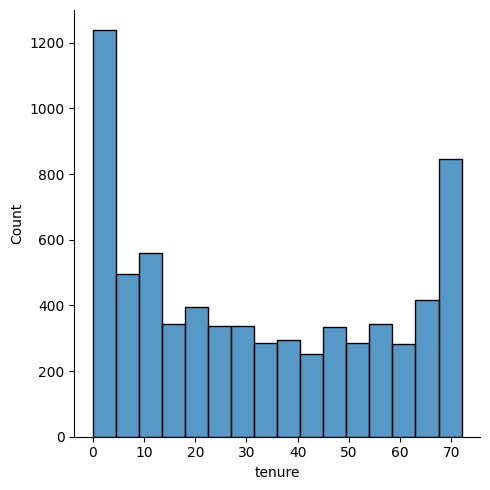

In [36]:
plt.figure(figsize=(16,5))

sns.displot(df['TotalCharges'])

sns.displot(df['MonthlyCharges'])

sns.displot(df['tenure'])
plt.show()

<Axes: ylabel='TotalCharges'>

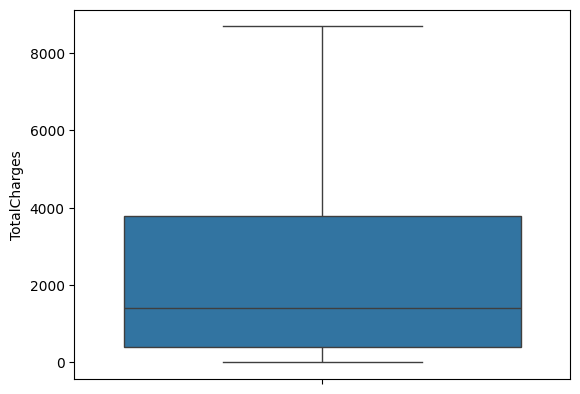

In [37]:
sns.boxplot(df['TotalCharges'])

<Axes: ylabel='MonthlyCharges'>

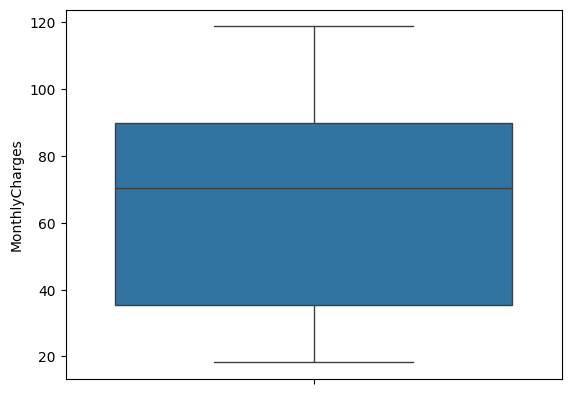

In [38]:
sns.boxplot(df['MonthlyCharges'])

<Axes: ylabel='tenure'>

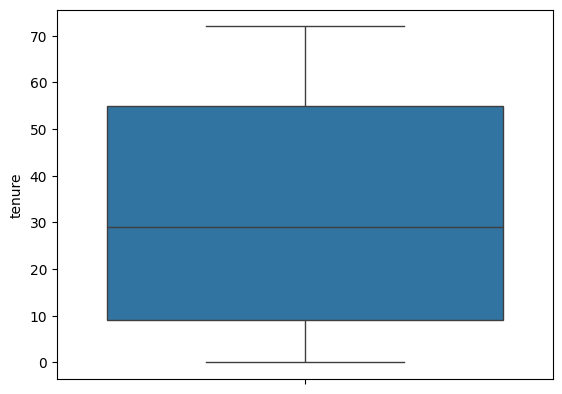

In [39]:
sns.boxplot(df['tenure'])

In [40]:
Q1 = df['TotalCharges'].quantile(0.25)
Q3 = df['TotalCharges'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df[(df['TotalCharges'] < lower) | (df['TotalCharges'] > upper)]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [41]:
df.head(4)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No


# Label Encoding 

In [42]:
''' from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for i in df_obj:
   
    df[i] = le.fit_transform(df[i])

'''
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in df_obj:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le   # save encoder

In [43]:
for col, le in encoders.items():
    print(f"{col}: {list(le.classes_)}")

gender: ['Female', 'Male']
Partner: ['No', 'Yes']
Dependents: ['No', 'Yes']
PhoneService: ['No', 'Yes']
MultipleLines: ['No', 'No phone service', 'Yes']
InternetService: ['DSL', 'Fiber optic', 'No']
OnlineSecurity: ['No', 'No internet service', 'Yes']
OnlineBackup: ['No', 'No internet service', 'Yes']
DeviceProtection: ['No', 'No internet service', 'Yes']
TechSupport: ['No', 'No internet service', 'Yes']
StreamingTV: ['No', 'No internet service', 'Yes']
StreamingMovies: ['No', 'No internet service', 'Yes']
Contract: ['Month-to-month', 'One year', 'Two year']
PaperlessBilling: ['No', 'Yes']
PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
Churn: ['No', 'Yes']


In [44]:
for col, le in encoders.items():
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col}: {mapping}")

gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Partner: {'No': np.int64(0), 'Yes': np.int64(1)}
Dependents: {'No': np.int64(0), 'Yes': np.int64(1)}
PhoneService: {'No': np.int64(0), 'Yes': np.int64(1)}
MultipleLines: {'No': np.int64(0), 'No phone service': np.int64(1), 'Yes': np.int64(2)}
InternetService: {'DSL': np.int64(0), 'Fiber optic': np.int64(1), 'No': np.int64(2)}
OnlineSecurity: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
OnlineBackup: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
DeviceProtection: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
TechSupport: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
StreamingTV: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
StreamingMovies: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
Contract: {'Month-to-month': np.int64(0), 'One year': np.int64(1), 'Two 

In [45]:
print("label encoding classes values: ")
print(le.classes_)

label encoding classes values: 
['No' 'Yes']


# Tasks 2: Split Data for Training and Testing:

<h5>Description:</h5>
<p></p>Divide the data into training (80%) and testing (20%) sets for model training and evaluation, ensuring a representative split.</p>

<h4>Skills:</h4>
<ul>
   <li>Data splitting methodologies</li> 
   <li>Understanding of training/testing dataset
requirements</li> 
</ul>

In [46]:
from sklearn.model_selection import train_test_split


In [47]:
X = df.drop(['Churn'],axis=1)

In [48]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65


In [49]:
Y = df['Churn']

In [50]:
Y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [51]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=13)

# Tasks 3: Feature Selection

In [52]:
from sklearn.feature_selection import SelectKBest, f_classif

In [53]:
selector = SelectKBest(score_func=f_classif, k=5)
#X_selected = selector.fit_transform(X,Y)

#selected_features = X.columns[selector.get_support()]

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

## Feature Scaling

In [54]:
from sklearn.preprocessing import StandardScaler

In [55]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

## Train Logistic Regression

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [57]:
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Predict on Test Data

In [58]:
y_pred = model.predict(X_test_scaled)

## Evaluate Model

In [59]:
logi_accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", logi_accuracy)

Accuracy: 0.8105039034776437


## See Selected Feature Names

In [60]:
selected_features = X.columns[selector.get_support()]
print(selected_features)

Index(['tenure', 'OnlineSecurity', 'TechSupport', 'Contract', 'TotalCharges'], dtype='str')


## Confusion Matrix (Recommended)

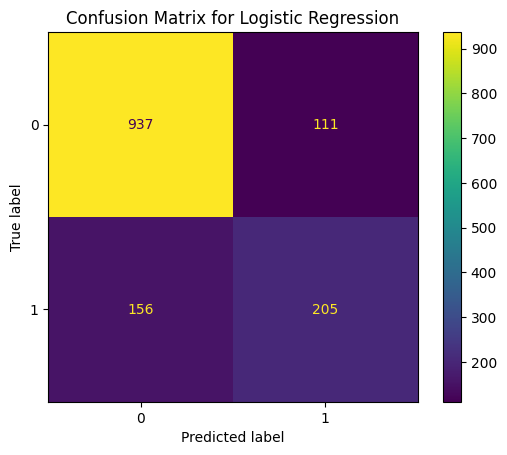

In [61]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix for Logistic Regression")
plt.show()

In [62]:
print("Accuracy:", logi_accuracy)

Accuracy: 0.8105039034776437


# Using Decition Tree

In [63]:
# Using Decition Tree
from sklearn.tree import DecisionTreeClassifier 
tree = DecisionTreeClassifier() 
tree.fit(X_train,y_train) 
tree_pred=tree.predict(X_test) 
tree_accuracy = accuracy_score(y_test,tree_pred) 
#print("Best Parameters:",grid.best_params_) 
print("Decision Tree Accuracy:",tree_accuracy)

Decision Tree Accuracy: 0.7224982256919801


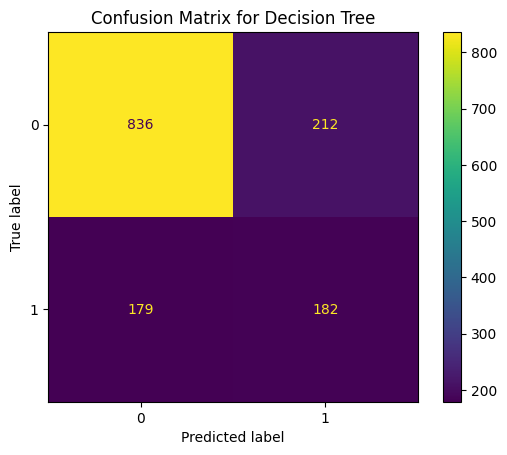

In [64]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, tree_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix for Decision Tree")
plt.show()

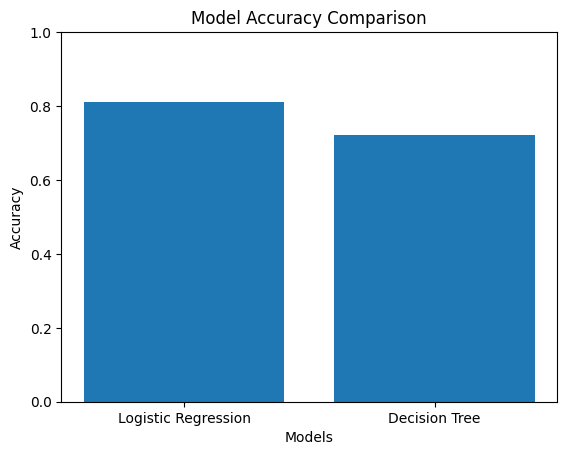

In [65]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree"]
accuracies = [logi_accuracy, tree_accuracy]  # logistic_accuracy from previous model

plt.figure()

plt.bar(models, accuracies)
plt.ylim(0,1)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

# Save Model + Preprocessing Objects

In [66]:
import pickle

# Save model
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save selector
with open("selector.pkl", "wb") as f:
    pickle.dump(selector, f)